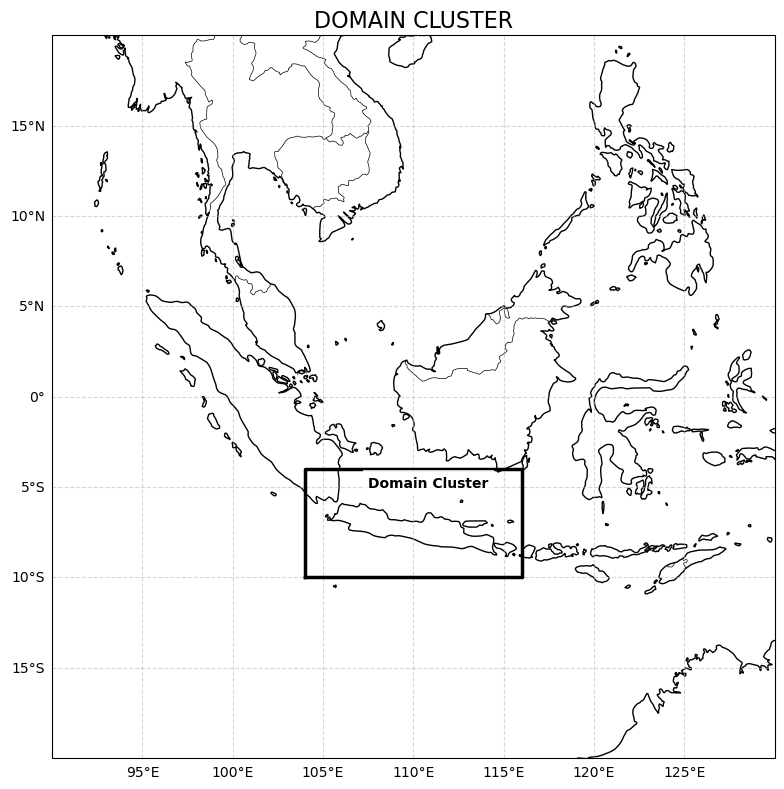

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([90, 130, -20, 20], crs=ccrs.PlateCarree())


# peta dasar
ax.coastlines(resolution='50m', linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# kotak CENS
lon_min, lon_max = 104, 116
lat_min, lat_max = -10, -4

ax.plot(
    [lon_min, lon_max, lon_max, lon_min, lon_min],
    [lat_min, lat_min, lat_max, lat_max, lat_min],
    color='black',
    linewidth=2.5,
    transform=ccrs.PlateCarree()
)

ax.text(
    107.5, -5,
    'Domain Cluster',
    color='black',
    fontsize=10,
    fontweight='bold',
    transform=ccrs.PlateCarree(),
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
)

plt.title('DOMAIN CLUSTER', fontsize=16)
plt.tight_layout()
plt.savefig('figure_output/box_domain_cluster.png', dpi=300, bbox_inches='tight')
plt.show()

## Potong Data Domain Jawa Lintang :-10, -4.0 Bujur : 104, 116.0

In [2]:
#Import package
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
from dask.diagnostics import ProgressBar

#Gead data
ds=xr.open_dataset('anomali_output/mswep_anrain_cens_DJF_1979_2025.nc')
OUT_FILE = "anomali_output/mswep_anrain_cens_DJF_1979_2025_jawa.nc"

t0 = datetime.now()
print("Mulai:", t0)

#Get the variables
rekstrem=ds.variables['precipitation'].values
lat=ds.variables['lat'].values
lon=ds.variables['lon'].values
time=ds.variables['time'].values

# 2) Deteksi nama koordinat yang tersedia
lat_name = 'lat' if 'lat' in ds.coords else ('latitude' if 'latitude' in ds.coords else None)
lon_name = 'lon' if 'lon' in ds.coords else ('longitude' if 'longitude' in ds.coords else None)
if lat_name is None or lon_name is None:
    raise ValueError(f"Koordinat lat/lon tidak ditemukan. Tersedia: {list(ds.coords)}")

# 3) Batas domain Pulau Jawa
lat_min, lat_max = -10, -4.0
lon_min, lon_max = 104, 116.0

# 4) Iris domain (order-agnostic, aman untuk lat menurun/menaik)
ds_jawa = ds.where(
    (ds[lat_name] >= min(lat_min, lat_max)) & (ds[lat_name] <= max(lat_min, lat_max)) &
    (ds[lon_name] >= lon_min) & (ds[lon_name] <= lon_max),
    drop=True
)

print("Ukuran setelah dipotong:", {k:int(v) for k,v in ds_jawa.sizes.items()})

# 5) simpan dengan progress
with ProgressBar():
    ds_jawa.to_netcdf(OUT_FILE)
    
t1 = datetime.now()
print("Saved:", OUT_FILE)
print("Selesai:", t1, "| durasi:", t1 - t0)

Mulai: 2026-04-28 17:18:13.915413
Ukuran setelah dipotong: {'time': 128, 'lat': 60, 'lon': 120}
Saved: anomali_output/mswep_anrain_cens_DJF_1979_2025_jawa.nc
Selesai: 2026-04-28 17:18:18.333889 | durasi: 0:00:04.418476


## Cek Data Hasil Potongan

Range colorbar simetris: -10.00 - 10.00


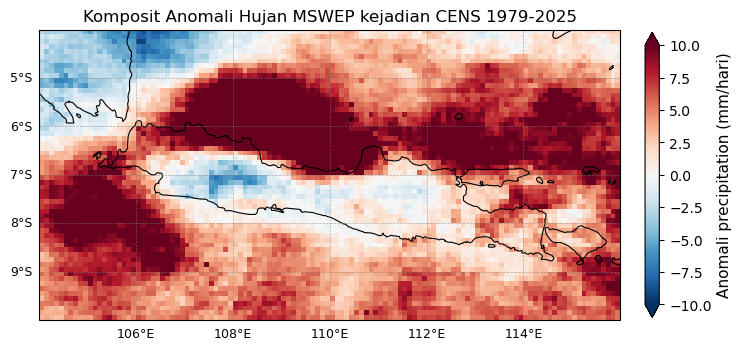

In [3]:
####### CEK DATA HASIL POTONG DENGAN PLOT RATA-RATA ANOMALI CURAH HUJAN (0 = putih)

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm   # <-- tambahan penting

# === Buka data ===
ds = xr.open_dataset("anomali_output/mswep_anrain_cens_DJF_1979_2025_jawa.nc")
var_name = list(ds.data_vars.keys())[0]
lon = ds["lon"]
lat = ds["lat"]

# === Hitung rata-rata anomali sepanjang waktu ===
mean_map = ds[var_name].mean(dim="time")

# === Tentukan range colorbar global ===
vmin_global = -10
vmax_global = 10
#vmin_global = float(mean_map.min())
#vmax_global = float(mean_map.max())

# Gunakan range simetris agar warna seimbang (0 putih)
absmax = max(abs(vmin_global), abs(vmax_global))
vmin_global, vmax_global = -absmax, absmax

print(f"Range colorbar simetris: {vmin_global:.2f} - {vmax_global:.2f}")

# === Plot rata-rata anomali ===
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# Normalisasi supaya 0 = putih
norm = TwoSlopeNorm(vmin=vmin_global, vcenter=0, vmax=vmax_global)

# Data anomali
mesh = ax.pcolormesh(
    lon, lat, mean_map,
    cmap="RdBu_r",           # merah-biru divergen
    norm=norm,               # <--- kunci agar 0 = putih
    transform=ccrs.PlateCarree()
)

# Tambahkan fitur peta
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5)

# Tentukan extent (Pulau Jawa)
ax.set_extent([104, 116, -10, -4], crs=ccrs.PlateCarree())

# === Tambahkan gridlines ===
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9}
gl.ylabel_style = {'size': 9}
gl.xlocator = plt.MultipleLocator(2.0)
gl.ylocator = plt.MultipleLocator(1.0)

# === Colorbar ===
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.023, pad=0.04, extend='both')
cbar.set_label(f"Anomali {var_name} (mm/hari)", fontsize=11)

# === Judul & simpan ===
ax.set_title("Komposit Anomali Hujan MSWEP kejadian CENS 1979-2025", fontsize=12)
plt.savefig("figure_output/mswep_mean_anomaly_jawa_map_white0_1979-2025.png", dpi=150, bbox_inches='tight')
plt.show()


Periode komposit: 1991–2025
Jumlah data waktu: 95
Range colorbar simetris: -10.00 - 10.00


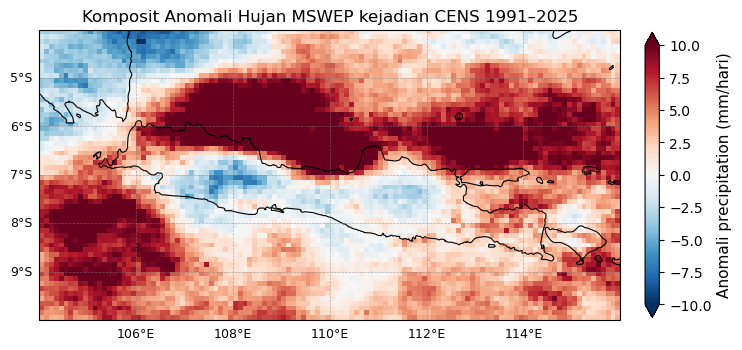

In [1]:
####### CEK DATA HASIL POTONG DENGAN PLOT RATA-RATA ANOMALI CURAH HUJAN (0 = putih)

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm

# === Buka data ===
ds = xr.open_dataset("anomali_output/mswep_anrain_cens_DJF_1979_2025_jawa.nc")
var_name = list(ds.data_vars.keys())[0]

# === Ambil data hanya periode 1991–2025 ===
ds = ds.sel(time=slice("1991-01-01", "2025-12-31"))

lon = ds["lon"]
lat = ds["lat"]

# === Hitung rata-rata anomali sepanjang waktu 1991–2025 ===
mean_map = ds[var_name].mean(dim="time", skipna=True)

# === Tentukan range colorbar global ===
vmin_global = -10
vmax_global = 10

# Gunakan range simetris agar warna seimbang (0 putih)
absmax = max(abs(vmin_global), abs(vmax_global))
vmin_global, vmax_global = -absmax, absmax

print(f"Periode komposit: 1991–2025")
print(f"Jumlah data waktu: {ds.sizes['time']}")
print(f"Range colorbar simetris: {vmin_global:.2f} - {vmax_global:.2f}")

# === Plot rata-rata anomali ===
fig, ax = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Normalisasi supaya 0 = putih
norm = TwoSlopeNorm(vmin=vmin_global, vcenter=0, vmax=vmax_global)

mesh = ax.pcolormesh(
    lon, lat, mean_map,
    cmap="RdBu_r",
    norm=norm,
    transform=ccrs.PlateCarree()
)

# Tambahkan fitur peta
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.5)

# Tentukan extent Pulau Jawa
ax.set_extent([104, 116, -10, -4], crs=ccrs.PlateCarree())

# === Gridlines ===
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color="gray",
    alpha=0.6,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}
gl.xlocator = plt.MultipleLocator(2.0)
gl.ylocator = plt.MultipleLocator(1.0)

# === Colorbar ===
cbar = fig.colorbar(
    mesh,
    ax=ax,
    orientation="vertical",
    fraction=0.023,
    pad=0.04,
    extend="both"
)
cbar.set_label(f"Anomali {var_name} (mm/hari)", fontsize=11)

# === Judul & simpan ===
ax.set_title(
    "Komposit Anomali Hujan MSWEP kejadian CENS 1991–2025",
    fontsize=12
)

plt.savefig(
    "figure_output/mswep_mean_anomaly_jawa_map_white0_1991-2025.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

Range colorbar ditetapkan: -20 .. 30


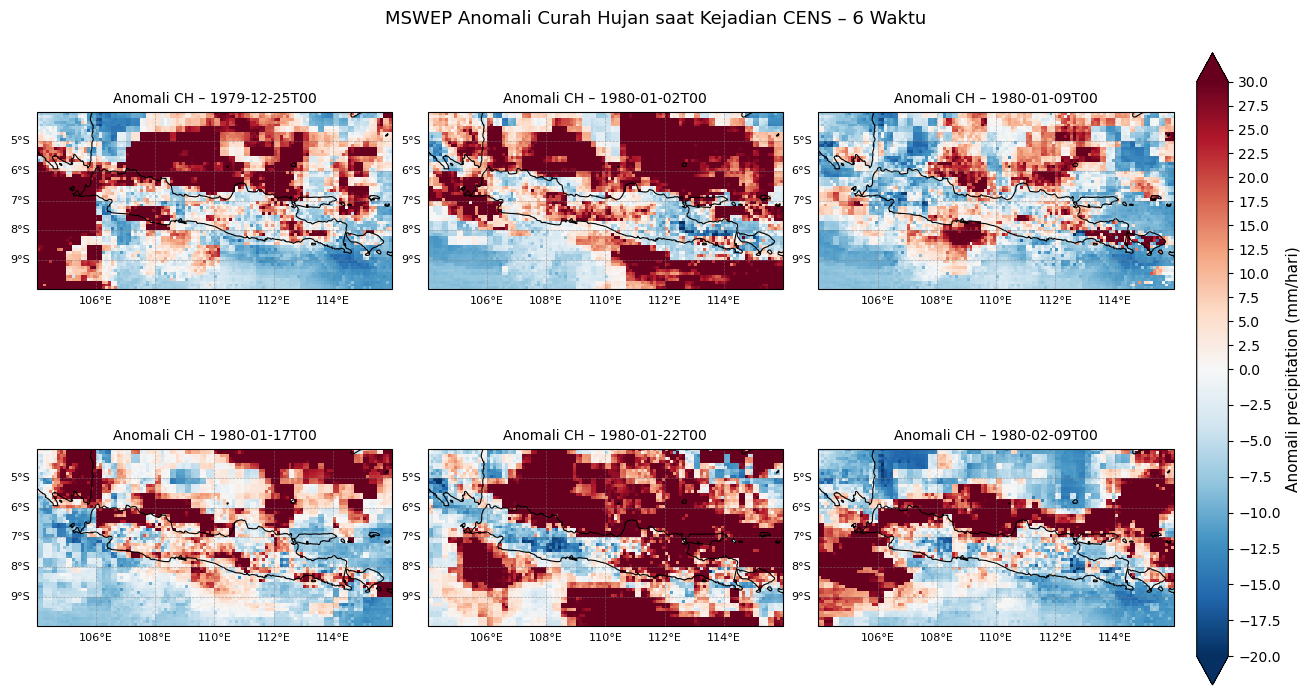

In [4]:
####### ANOMALI CURAH HUJAN per-waktu (6 panel, 0 = putih)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MultipleLocator

# === Buka data ===
ds = xr.open_dataset("anomali_output/mswep_anrain_cens_DJF_1979_2025_jawa.nc")
var_name = list(ds.data_vars.keys())[0]
lon = ds["lon"]
lat = ds["lat"]
time = ds["time"].values  # np.datetime64 array

# === Pilih 6 waktu pertama (atau kurang jika data < 6) ===
n_panel = min(6, time.size)
times_sel = time[:n_panel]

# === Atur rentang warna global tetap ===
vmin_global = -20
vmax_global = 30
print(f"Range colorbar ditetapkan: {vmin_global} .. {vmax_global}")

# === Siapkan figure 2 x 3 ===
fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 7),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# === Colormap divergen (0 = putih) ===
cmap = "RdBu_r"
norm = TwoSlopeNorm(vmin=vmin_global, vcenter=0, vmax=vmax_global)

last_mesh = None

for i, tsel in enumerate(times_sel):
    ax = axes.ravel()[i]

    # Data anomali pada waktu tsel
    amap = ds[var_name].sel(time=tsel)

    # Plot
    mesh = ax.pcolormesh(
        lon, lat, amap,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree()
    )
    last_mesh = mesh

    # Fitur peta
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5)

    # Extent Pulau Jawa (aktifkan jika mau fokus Jawa)
    ax.set_extent([104, 116, -10, -4], crs=ccrs.PlateCarree())

    # Gridlines (rapi: label hanya kiri & bawah)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xlocator = MultipleLocator(2.0)
    gl.ylocator = MultipleLocator(1.0)

    # Judul panel dengan waktu (format ringkas)
    tstr = np.datetime_as_string(tsel, unit='h')
    ax.set_title(f"Anomali CH – {tstr}", fontsize=10)

# Sembunyikan panel sisa jika data < 6
for j in range(n_panel, 6):
    axes.ravel()[j].set_visible(False)

# === Colorbar bersama (kanan) ===
cbar = fig.colorbar(
    last_mesh, ax=axes.ravel().tolist(),
    orientation='vertical', fraction=0.03, pad=0.02, shrink=0.95, extend='both'
)

cbar.set_label(f"Anomali {var_name} (mm/hari)", fontsize=11)
cbar.set_ticks(np.arange(vmin_global, vmax_global + 2.5, 2.5))

# Judul umum & simpan
fig.suptitle("MSWEP Anomali Curah Hujan saat Kejadian CENS – 6 Waktu", fontsize=13)
plt.savefig("figure_output/mswep_anomali_ch_6panel_awal_1979_2025.png", dpi=200, bbox_inches='tight')
plt.show()


Range colorbar ditetapkan: -20 .. 30


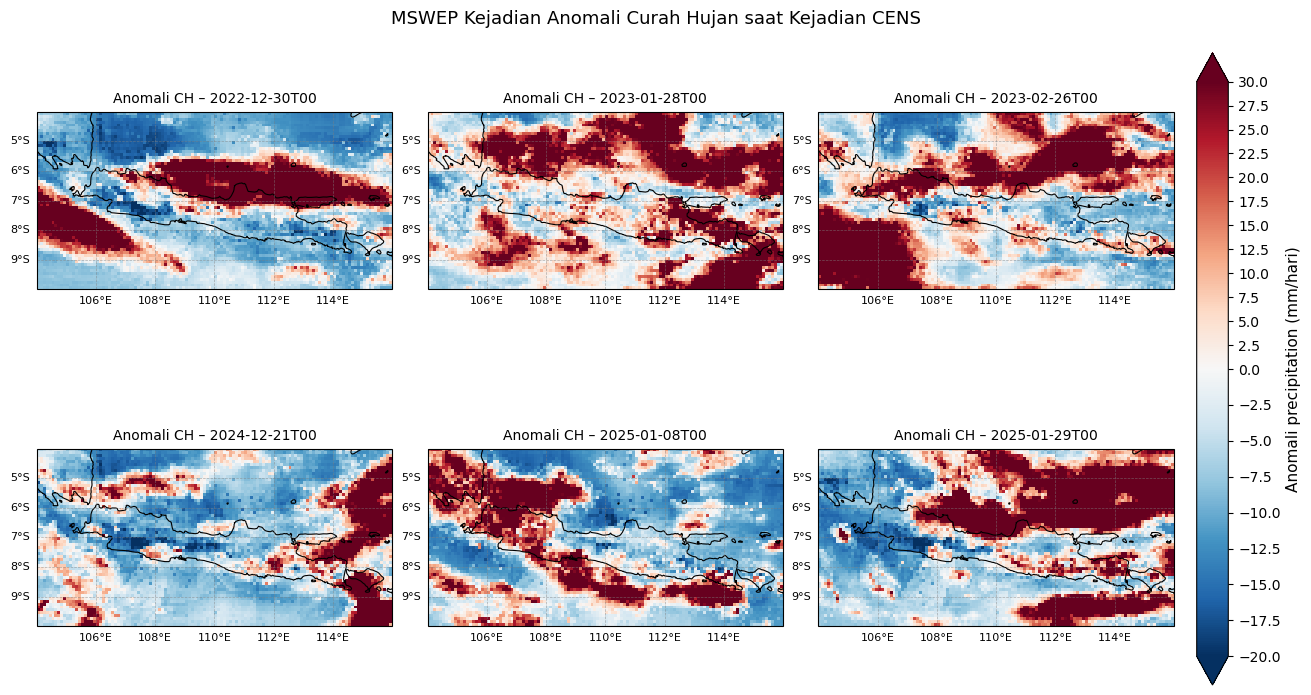

In [5]:
####### ANOMALI CURAH HUJAN per-waktu (6 panel terakhir, 0 = putih, range -5 s.d. 20)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MultipleLocator

# === Buka data ===
ds = xr.open_dataset("anomali_output/mswep_anrain_cens_DJF_1979_2025_jawa.nc")
var_name = list(ds.data_vars.keys())[0]
lon = ds["lon"]
lat = ds["lat"]
time = ds["time"].values  # np.datetime64 array

# === Pilih 6 waktu TERAKHIR (atau kurang jika data < 6) ===
n_panel = min(6, time.size)
times_sel = time[-n_panel:]  # ambil waktu paling akhir

# === Atur rentang warna global tetap ===
vmin_global = -20
vmax_global = 30
print(f"Range colorbar ditetapkan: {vmin_global} .. {vmax_global}")

# === Normalisasi agar 0 = putih ===
cmap = "RdBu_r"
norm = TwoSlopeNorm(vmin=vmin_global, vcenter=0, vmax=vmax_global)

# === Siapkan figure 2x3 ===
fig, axes = plt.subplots(
    2, 3,
    figsize=(13, 7),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

last_mesh = None

# === Loop tiap waktu ===
for i, tsel in enumerate(times_sel):
    ax = axes.ravel()[i]

    # Data anomali pada waktu tsel
    amap = ds[var_name].sel(time=tsel)

    # Plot
    mesh = ax.pcolormesh(
        lon, lat, amap,
        cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree()
    )
    last_mesh = mesh

    # Fitur peta
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=0.5)

    # Fokus Pulau Jawa
    ax.set_extent([104, 116, -10, -4], crs=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xlocator = MultipleLocator(2.0)
    gl.ylocator = MultipleLocator(1.0)

    # Judul panel waktu
    tstr = np.datetime_as_string(tsel, unit='h')
    ax.set_title(f"Anomali CH – {tstr}", fontsize=10)

# === Sembunyikan panel kosong jika data < 6 ===
for j in range(n_panel, 6):
    axes.ravel()[j].set_visible(False)

# === Colorbar bersama ===
cbar = fig.colorbar(
    last_mesh, ax=axes.ravel().tolist(),
    orientation='vertical', fraction=0.03, pad=0.02,
    shrink=0.95, extend='both'
)
cbar.set_label(f"Anomali {var_name} (mm/hari)", fontsize=11)
cbar.set_ticks(np.arange(vmin_global, vmax_global + 2.5, 2.5))

# === Judul utama & simpan ===
fig.suptitle("MSWEP Kejadian Anomali Curah Hujan saat Kejadian CENS", fontsize=13)
plt.savefig("figure_output/mswep_anomali_ch_6panel_terakhir_1979_2025.png", dpi=200, bbox_inches='tight')
plt.show()


## MEMBUAT CLUSTER Dengan Metode Elbow

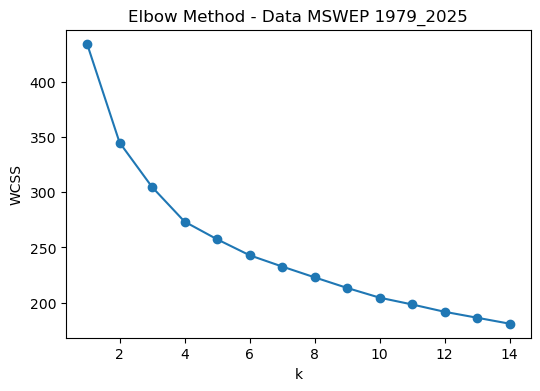

In [42]:
#Import package
from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.basemap import Basemap

#Gead data
data=xr.open_dataset('anomali_output/mswep_anrain_cens_DJF_1979_2025_jawa.nc')

#Get the variables
# rekstrem=data.variables['precipitation'].values
lat=data.variables['lat'].values
lon=data.variables['lon'].values
time=data.variables['time'].values

#Calculate correlation matrix
corrmat=np.empty([len(time),len(time)])
for i in range (len(time)):
    for j in range (len(time)):
        corrmat[i,j]=xr.corr(data['precipitation'][i], data['precipitation'][j])
corr = pd.DataFrame(corrmat)

#Plot elbow method
sse = []
k_list = range(1, 15)
for k in k_list:
    km = KMeans(n_clusters=k, n_init=500, max_iter=800) #kalau terlalu lama bisa dikurangi
    km.fit(corr)
    sse.append([k, km.inertia_])
    
elbow_results_scale = pd.DataFrame({'Cluster': range(1,15), 'SSE': sse})

plt.figure(figsize=(6,4))
plt.plot(pd.DataFrame(sse)[0], pd.DataFrame(sse)[1], marker='o')
plt.title('Elbow Method - Data MSWEP 1979_2025')
plt.xlabel('k')
plt.ylabel('WCSS')
plt.savefig('figure_output/mswep_1979_2025_Elbow method.png', dpi=300)
plt.show()

## Dari Hasil Plot Elbow Dipilih Jumlah Cluster 4

In [43]:
#Choose number of cluster (k)
n_clust = 4

#K means clustering
kmeans_scale = KMeans(n_clusters=n_clust,
                      n_init=500, max_iter=800, #kalau terlalu lama bisa dikurangi
                      init='k-means++')
kmeans_scale.fit(corr)
labels_scale = kmeans_scale.labels_
clusters_scale = pd.concat([corr, pd.DataFrame({'clusters':labels_scale})], axis=1)

#Dataframe time event-cluster
Hasil = pd.DataFrame({'tanggal': time, 'cluster': labels_scale})
Hasil = Hasil.set_index('tanggal')

## Menyimpan Hasil Clustering Ke File Excel

In [44]:
Hasil_reset = Hasil.reset_index().rename(columns={'tanggal':'tanggal', 'cluster':'cluster'})
Hasil_reset['tanggal'] = pd.to_datetime(Hasil_reset['tanggal'])

with pd.ExcelWriter(
    'calculation_output/mswep_Tanggal-ClusterDJF-1979_2025-4cluster.xlsx',
    engine='openpyxl',
    datetime_format='yyyy-mm-dd',
    date_format='yyyy-mm-dd'
) as writer:
    Hasil_reset.to_excel(writer, sheet_name='Hasil', index=False)

print("OK: Tersimpan (format tanggal yyyy-mm-dd)")


OK: Tersimpan (format tanggal yyyy-mm-dd)


## Mengidentifikasi Number Of Events

In [49]:
#Import package
import pandas as pd

#Read time-cluster excel data
cluster=pd.read_excel('calculation_output/mswep_Tanggal-ClusterDJF-1979_2025-4cluster.xlsx')
cluster=cluster.set_index('tanggal')

#Date extreme rainfall event each cluster
n_clust = 4
kejadian_clust = []
for i in range(n_clust):
    kejadian = cluster[cluster['cluster'] == i].index
    print("Banyak kejadian cluster {i} = {n} dari {x}".format(i=i, n=len(kejadian), x=len(cluster)))
    print("Banyak kejadian cluster {i} = {n}%".format(i=i, n=(len(kejadian)*100/len(cluster.index))))
    kejadian_clust.append(kejadian.values)

Banyak kejadian cluster 0 = 42 dari 128
Banyak kejadian cluster 0 = 32.8125%
Banyak kejadian cluster 1 = 31 dari 128
Banyak kejadian cluster 1 = 24.21875%
Banyak kejadian cluster 2 = 22 dari 128
Banyak kejadian cluster 2 = 17.1875%
Banyak kejadian cluster 3 = 33 dari 128
Banyak kejadian cluster 3 = 25.78125%


<Figure size 700x300 with 0 Axes>

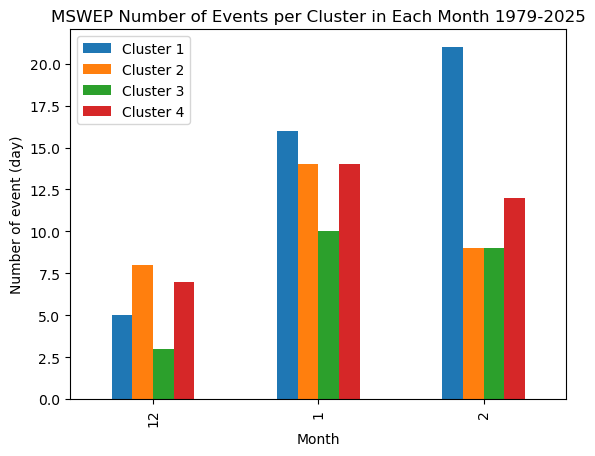

In [50]:
#Import package
import matplotlib.pyplot as plt

#Plot number of events per cluster in each month
clust_frek = cluster.groupby(cluster.index.month).count()
label_frek_clust = []

for i in range(n_clust):
    xx = cluster[cluster['cluster'] == i]
    xx = xx.groupby(xx.index.month).count()
    label_frek_clust.append(xx['cluster'].rename('Cluster {}'.format(i+1)))
    
df_label_frek_clust = pd.DataFrame(label_frek_clust).transpose()
df_label_frek_clust = df_label_frek_clust.reindex([12,1,2])

plt.figure(figsize=(7,3))
df_label_frek_clust.plot(kind='bar')

plt.xlabel("Month"); plt.ylabel("Number of event (day)"); 
plt.title("MSWEP Number of Events per Cluster in Each Month 1979-2025")
plt.savefig('figure_output/mswep number of events per cluster in each month 1979_2025.png', dpi=300)
plt.show()

<Figure size 700x300 with 0 Axes>

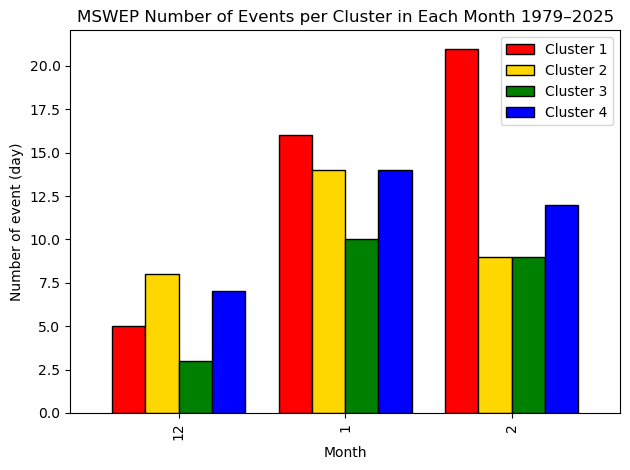

In [51]:
# =========================
# IMPORT
# =========================
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# WARNA CLUSTER
# =========================
cluster_colors = ['red', 'gold', 'green', 'blue']

# =========================
# HITUNG FREKUENSI PER BULAN
# =========================
label_frek_clust = []

# pastikan cluster = 1–4
if cluster['cluster'].min() == 0:
    cluster['cluster'] += 1

for i in range(1, n_clust + 1):
    xx = cluster[cluster['cluster'] == i]
    xx = xx.groupby(xx.index.month).count()

    label_frek_clust.append(
        xx['cluster'].rename(f'Cluster {i}')
    )

df_label_frek_clust = pd.DataFrame(label_frek_clust).transpose()

# urutan DJF
df_label_frek_clust = df_label_frek_clust.reindex([12, 1, 2])

# =========================
# PLOT
# =========================
plt.figure(figsize=(7, 3))

df_label_frek_clust.plot(
    kind='bar',
    color=cluster_colors,
    edgecolor='black',
    width=0.8
)

plt.xlabel("Month")
plt.ylabel("Number of event (day)")
plt.title("MSWEP Number of Events per Cluster in Each Month 1979–2025")

#plt.legend(title='Cluster')

plt.tight_layout()

plt.savefig(
    'figure_output/mswep number of events per cluster in each month 1979_2025.png',
    dpi=300
)

plt.show()

### COBA GAMBAR DIEKSTEND DITAMBAHKAN ANGIN

/tmp/ipykernel_296243/175994.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  seismic =cm.get_cmap('seismic_r', 100)


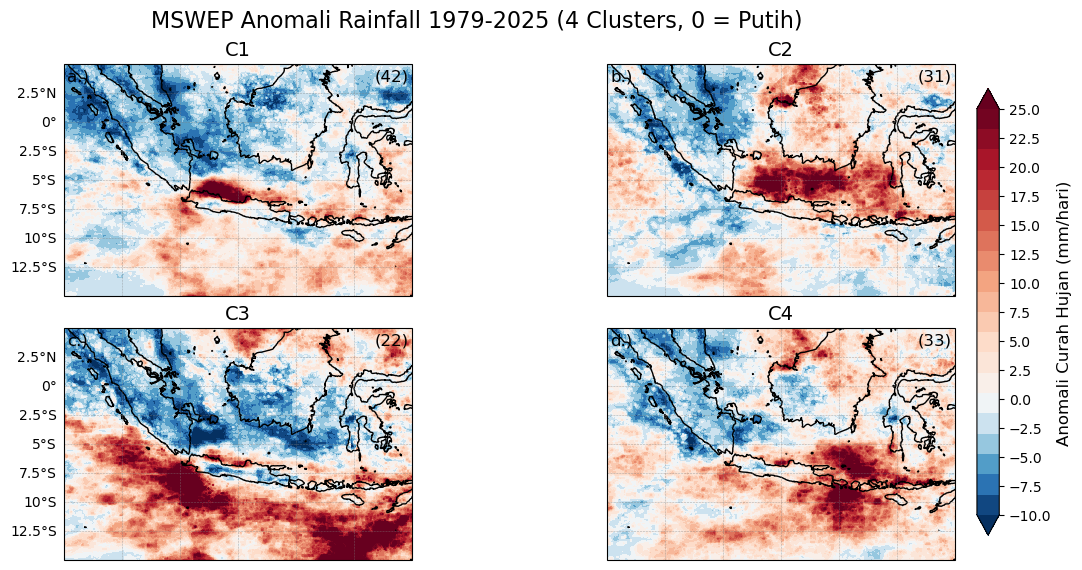

In [52]:
#Import package
from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.basemap import Basemap
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

#Read data
data=xr.open_dataset('anomali_output/mswep_anrain_cens_DJF_1979_2025.nc')

#Get the variables
rekstrem=data.variables['precipitation'].values
lat=data.variables['lat'].values
lon=data.variables['lon'].values
time=data.variables['time'].values

#Read time-cluster excel data
cluster=pd.read_excel('calculation_output/mswep_Tanggal-ClusterDJF-1979_2025-4cluster.xlsx')
cluster=cluster.set_index('tanggal')

#cmap settings
seismic =cm.get_cmap('seismic_r', 100)
newc = seismic(np.linspace(0,1,100))
white = np.array([255/256, 255/256, 255/256, 1])
newc = newc[50:,:]
newc[:3, :] = white
cmap = ListedColormap(newc)

# --- Plot rerata hujan per cluster (Cartopy) versi lebar & rapi (4 cluster, 0 = putih) ---

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import TwoSlopeNorm     # ⬅️ tambahan penting
import numpy as np
import matplotlib.pyplot as plt

alph = ["a", "b", "c", "d"]
nperclust = np.array([len(k) for k in kejadian_clust])
n_clust = 4   # jumlah cluster yang ingin ditampilkan

# domain dari data
LAT_MIN, LAT_MAX = float(np.min(lat)), float(np.max(lat))
LON_MIN, LON_MAX = float(np.min(lon)), float(np.max(lon))

lon2d, lat2d = np.meshgrid(lon, lat)
projection = ccrs.PlateCarree()

# >>> figure grid 3x2 (agar proporsional, tapi nanti panel sisa disembunyikan)
nrows, ncols = 3, 2
fig, axes = plt.subplots(
    nrows, ncols,
    subplot_kw={'projection': projection},
    figsize=(12, 8),
    constrained_layout=True
)

last_pcm = None

# ==== 💡 Atur range warna ====
vmin, vmax = -10, 25
levels = np.linspace(vmin, vmax, 21)
cmap_name = 'RdBu_r'

# Gunakan TwoSlopeNorm supaya 0 = putih
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

for i in range(n_clust):
    ax = axes.ravel()[i]

    # extent + layer peta (fokus Jawa)
#    ax.set_extent([104, 116, -10, -4], crs=ccrs.PlateCarree())
    ax.set_extent([95, 125, -15, 5], crs=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='lightgray', alpha=0.3)
    ax.coastlines(resolution='10m', linewidth=1.0, color='black')
    
    # gridlines
    row, col = divmod(i, ncols)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels  = (col == 0)
    gl.bottom_labels = (row == nrows - 1)
    ax.xaxis.set_major_locator(MultipleLocator(2.5))
    ax.yaxis.set_major_locator(MultipleLocator(2.5))

    # ambil mean atas waktu kejadian cluster i
    dset = data[var_name]
    times_i = kejadian_clust[i]
    if times_i.size == 0:
        value = np.full((lat.size, lon.size), np.nan)
    else:
        value = dset.sel(time=times_i).mean(dim='time', skipna=True).values

    # ==== Plot dengan norm agar 0 = putih ====
    pcm = ax.contourf(
        lon2d, lat2d, value,
        levels=levels,
        cmap=cmap_name,
        norm=norm,                 # ⬅️ inilah kuncinya
        extend='both',
        transform=ccrs.PlateCarree()
    )
    last_pcm = pcm

    # judul & anotasi
    ax.set_title(f"C{i+1}", fontsize=14)
    ax.text(0.01, 0.98, f"{alph[i]}.)", transform=ax.transAxes, fontsize=12, va='top')
    ax.text(0.99, 0.98, f"({int(nperclust[i])})", transform=ax.transAxes, fontsize=12, va='top', ha='right')

# ==== 🔹 Sembunyikan panel ke-5 & ke-6 (kosong) ====
for j in range(n_clust, nrows * ncols):
    axes.ravel()[j].set_visible(False)

# ==== Colorbar bersama ====
cbar = fig.colorbar(
    last_pcm,
    ax=[ax for ax in axes.ravel() if ax.get_visible()],
    location='right',
    shrink=0.9,
    pad=0.02,
    extend='both'
)
cbar.set_label('Anomali Curah Hujan (mm/hari)', fontsize=12)
cbar.set_ticks(np.arange(vmin, vmax + 1, 2.5))

fig.suptitle('MSWEP Anomali Rainfall 1979-2025 (4 Clusters, 0 = Putih)', fontsize=16)
plt.savefig('figure_output/mswep_Anomali_rainfall_4cluster_white0-extend 1979_2025.png', dpi=300)
plt.show()


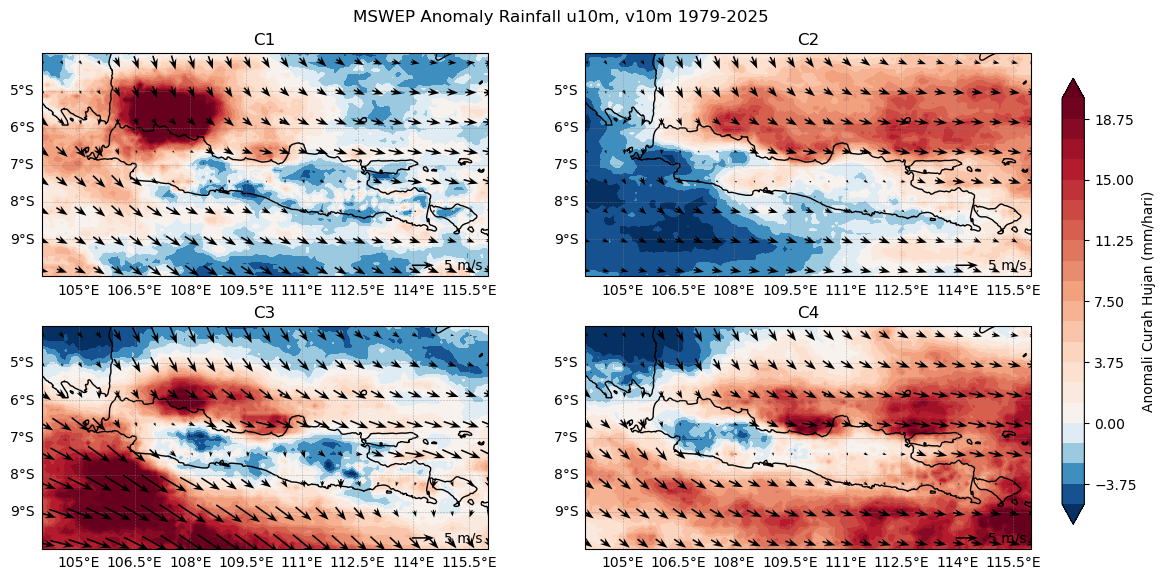

In [11]:
# ======================================================
# PLOT KOMPOSIT HUJAN PER CLUSTER + OVERLAY ERA5 WIND
# ======================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import TwoSlopeNorm

# =========================
# 1) BACA DATA
# =========================

rain = xr.open_dataset('mswep_anraincens_1979_2025.nc')
u10  = xr.open_dataset('anu10mcens_197912_202502.nc')
v10  = xr.open_dataset('anv10mcens_197912_202502.nc')

# OUTPUT FILE
OUTFILE = 'pic-cluster4/mswep_u10v10_Anomali_rainfall_4cluster_1979_2025_jawa.png'

# JUDUL
JUDUL = "MSWEP Anomaly Rainfall u10m, v10m 1979-2025"

lat = rain['lat'].values
lon = rain['lon'].values

lon2d, lat2d = np.meshgrid(lon, lat)

# =========================
# 2) PARAMETER PLOT
# =========================

n_clust = 4
alph = ["a","b","c","d"]

vmin = -5
vmax = 20
levels = np.linspace(vmin, vmax, 21)

norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    3,2,
    subplot_kw={'projection':projection},
    figsize=(12,8),
    constrained_layout=True
)

# =========================
# 3) LOOP CLUSTER
# =========================

for i in range(n_clust):

    ax = axes.ravel()[i]

    # extent Indo Bg Barat
    # ax.set_extent([102,118,-11,0], crs=ccrs.PlateCarree())

    # extent Jawa
    ax.set_extent([104, 116, -10, -4], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND.with_scale('10m'),
                   facecolor='lightgray', alpha=0.3)

    ax.coastlines(resolution='10m', linewidth=1)

    gl = ax.gridlines(draw_labels=True,
                      linewidth=0.4,
                      color='gray',
                      linestyle='--',
                      alpha=0.6)

    gl.top_labels=False
    gl.right_labels=False

    ax.xaxis.set_major_locator(MultipleLocator(2.5))
    ax.yaxis.set_major_locator(MultipleLocator(2.5))

    # =========================
    # ambil waktu cluster
    # =========================

    times_i = kejadian_clust[i]

    rain_mean = rain['precipitation'].sel(time=times_i).mean('time')

    u_mean = u10['u10'].sel(time=times_i).mean('time')
    v_mean = v10['v10'].sel(time=times_i).mean('time')

    # samakan grid
    u_mean = u_mean.interp(lat=rain.lat, lon=rain.lon)
    v_mean = v_mean.interp(lat=rain.lat, lon=rain.lon)

    # =========================
    # PLOT HUJAN
    # =========================

    pcm = ax.contourf(
        lon2d, lat2d,
        rain_mean,
        levels=levels,
        cmap='RdBu_r',
        norm=norm,
        extend='both',
        transform=ccrs.PlateCarree()
    )

    # =========================
    # OVERLAY ANGIN
    # =========================

    u_dom = u_mean.values
    v_dom = v_mean.values

    lat_w = u_mean['lat'].values
    lon_w = u_mean['lon'].values

    # kepadatan panah
    step_x = max(1, len(lon_w)//60)
    step_y = max(1, len(lat_w)//36)

    if np.isfinite(u_dom).any():

        qv = ax.quiver(
            lon_w[::step_x],
            lat_w[::step_y],
            u_dom[::step_y,::step_x],
            v_dom[::step_y,::step_x],

            transform=ccrs.PlateCarree(),

            scale=100,
            width=0.0035,
            pivot='mid',

            headwidth=5,
            headlength=7,
            headaxislength=5,

            color='k',
            zorder=4
        )

        ax.quiverkey(
            qv,
            0.88,0.05,
            5,
            '5 m/s',
            labelpos='E',
            coordinates='axes'
        )

    ax.set_title(f"C{i+1}")

# =========================
# sembunyikan panel kosong
# =========================

for j in range(n_clust,6):
    axes.ravel()[j].set_visible(False)

# =========================
# COLORBAR
# =========================

cbar = fig.colorbar(
    pcm,
    ax=[ax for ax in axes.ravel() if ax.get_visible()],
    location='right',
    shrink=0.9,
    pad=0.02
)

cbar.set_label("Anomali Curah Hujan (mm/hari)")

fig.suptitle(JUDUL)

plt.savefig(
    OUTFILE,
    dpi=300
)

plt.show()

/tmp/ipykernel_96645/435025378.py:176: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


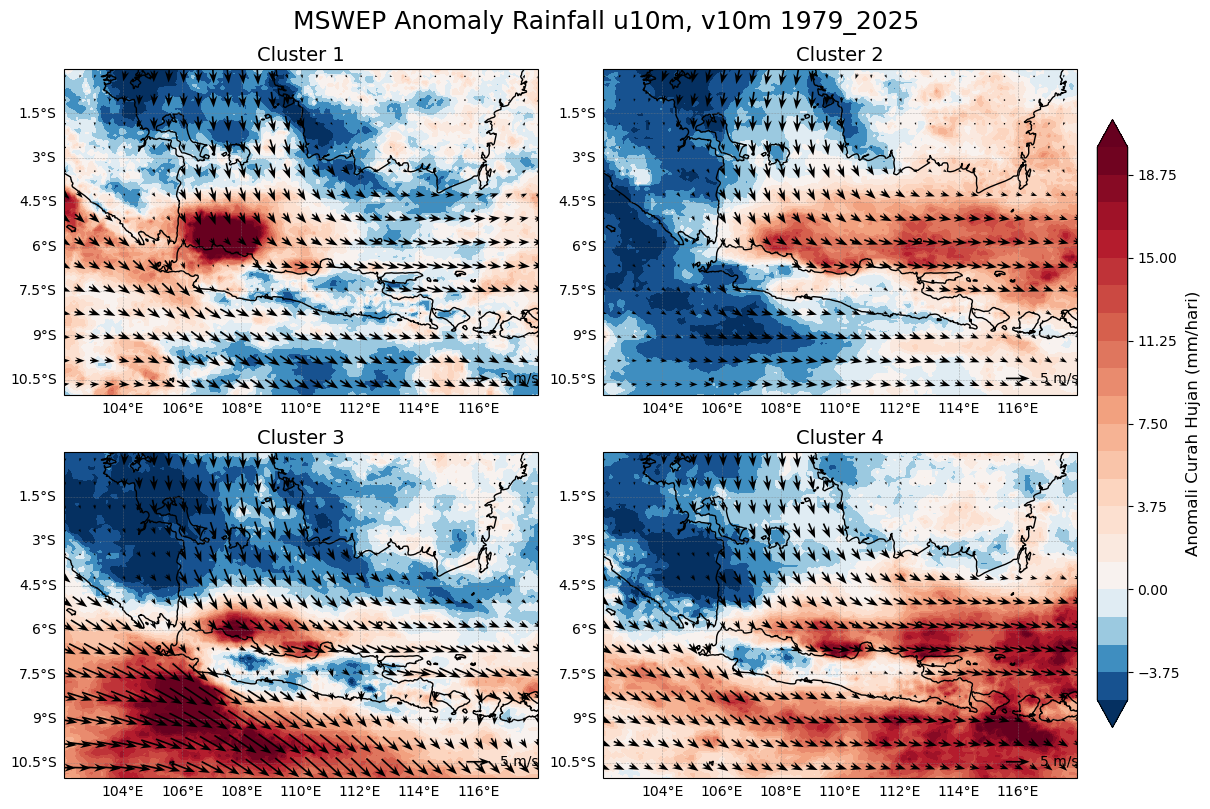

In [12]:
# ======================================================
# PLOT KOMPOSIT HUJAN PER CLUSTER + OVERLAY ERA5 WIND
# FULL SCREEN VERSION
# ======================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import TwoSlopeNorm

# =========================
# 1) BACA DATA
# =========================

rain = xr.open_dataset('mswep_anraincens_1979_2025.nc')
u10  = xr.open_dataset('anu10mcens_197912_202502.nc')
v10  = xr.open_dataset('anv10mcens_197912_202502.nc')

OUTFILE = 'pic-cluster4/mswep_u10v10_Anomali_rainfall_4cluster_1979_2025_west.png'
JUDUL = "MSWEP Anomaly Rainfall u10m, v10m 1979_2025"

lat = rain['lat'].values
lon = rain['lon'].values
lon2d, lat2d = np.meshgrid(lon, lat)

# =========================
# 2) PARAMETER PLOT
# =========================

n_clust = 4

vmin = -5
vmax = 20
levels = np.linspace(vmin, vmax, 21)

norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

projection = ccrs.PlateCarree()

# ===== FULL SCREEN FIGURE =====
fig, axes = plt.subplots(
    2,2,
    subplot_kw={'projection':projection},
    figsize=(12,8),   # <<< diperbesar
    constrained_layout=True
)


axes = axes.flatten()

# =========================
# 3) LOOP CLUSTER
# =========================

for i in range(n_clust):

    ax = axes[i]

    # extent Indo Barat
    ax.set_extent([102,118,-11,0], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND.with_scale('10m'),
                   facecolor='lightgray', alpha=0.3)

    ax.coastlines(resolution='10m', linewidth=1)

    gl = ax.gridlines(draw_labels=True,
                      linewidth=0.4,
                      color='gray',
                      linestyle='--',
                      alpha=0.6)

    gl.top_labels=False
    gl.right_labels=False

    ax.xaxis.set_major_locator(MultipleLocator(2.5))
    ax.yaxis.set_major_locator(MultipleLocator(2.5))

    # =========================
    # ambil waktu cluster
    # =========================

    times_i = kejadian_clust[i]

    rain_mean = rain['precipitation'].sel(time=times_i).mean('time')

    u_mean = u10['u10'].sel(time=times_i).mean('time')
    v_mean = v10['v10'].sel(time=times_i).mean('time')

    # samakan grid
    u_mean = u_mean.interp(lat=rain.lat, lon=rain.lon)
    v_mean = v_mean.interp(lat=rain.lat, lon=rain.lon)

    # =========================
    # PLOT HUJAN
    # =========================

    pcm = ax.contourf(
        lon2d, lat2d,
        rain_mean,
        levels=levels,
        cmap='RdBu_r',
        norm=norm,
        extend='both',
        transform=ccrs.PlateCarree()
    )

    # =========================
    # OVERLAY ANGIN
    # =========================

    u_dom = u_mean.values
    v_dom = v_mean.values

    lat_w = u_mean['lat'].values
    lon_w = u_mean['lon'].values

    step_x = max(1, len(lon_w)//60)
    step_y = max(1, len(lat_w)//36)

    if np.isfinite(u_dom).any():

        qv = ax.quiver(
            lon_w[::step_x],
            lat_w[::step_y],
            u_dom[::step_y,::step_x],
            v_dom[::step_y,::step_x],

            transform=ccrs.PlateCarree(),

            scale=100,
            width=0.0035,
            pivot='mid',

            headwidth=5,
            headlength=7,
            headaxislength=5,

            color='k',
            zorder=4
        )

        ax.quiverkey(
            qv,
            0.90,0.05,
            5,
            '5 m/s',
            labelpos='E',
            coordinates='axes'
        )

    ax.set_title(f"Cluster {i+1}", fontsize=14)

# =========================
# COLORBAR
# =========================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    orientation='vertical',
    fraction=0.03,
    pad=0.02
)

cbar.set_label("Anomali Curah Hujan (mm/hari)", fontsize=12)

fig.suptitle(JUDUL, fontsize=18)

# hilangkan ruang kosong
plt.subplots_adjust(
    left=0.05,
    right=0.92,
    bottom=0.05,
    top=0.92,
    wspace=0.05,
    hspace=0.08
)

plt.savefig(
    OUTFILE,
    dpi=300,
    bbox_inches='tight'
)

plt.show()